昨天的作业，这里直接拿过来使用了

matplotlib 3.10.0
numpy 2.1.3
pandas 2.2.3
sklearn 1.8.0
torch 2.9.1+cu130
图像大小: (28, 28)
图像模式: L
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183,

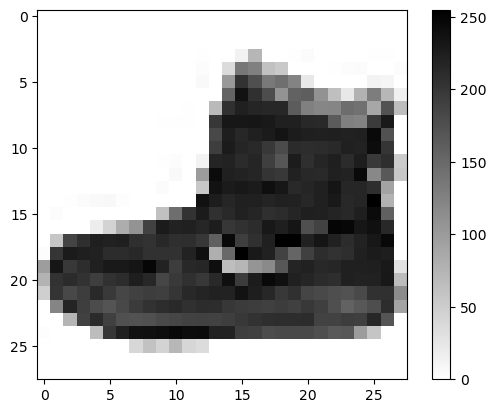

In [1]:
#昨天的代码
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm 
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms

for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")


train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=None
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=None
)

img, label = train_ds[0]

def show_img_content(img):
    from PIL import Image

    print("图像大小:", img.size)
    print("图像模式:", img.mode)

    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)
show_img_content(img)

def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary") # 显示图片
    plt.colorbar() # 显示颜色条
    plt.show()

show_single_image(img)

训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


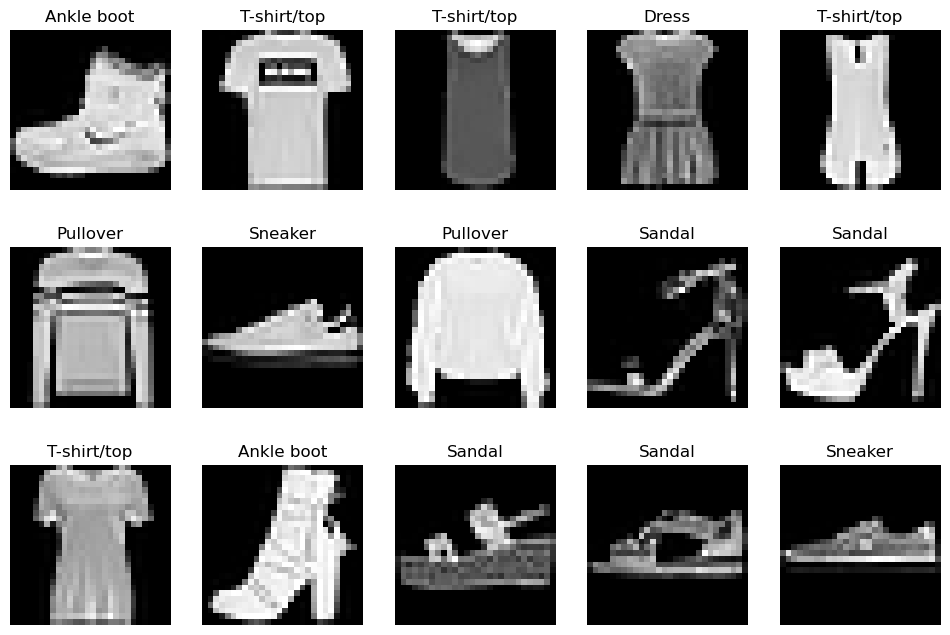

In [2]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")
print(train_dataset.classes)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i in range(15):
    ax = axes[i//5, i%5]
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(class_names[train_dataset[i][1]])
    ax.axis('off')
plt.show()

In [3]:
batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"训练集批次数量: {len(train_loader)}")
print(f"测试集批次数量: {len(test_loader)}")
print(f"每个批次样本数量: {batch_size}")

train_features, train_labels = next(iter(train_loader))
print(f"训练集第一个批次特征形状: {train_features.shape}")
print(f"训练集第一个批次标签形状: {train_labels.shape}")
print(f"训练集第一个批次标签: {train_labels}")

训练集批次数量: 1875
测试集批次数量: 313
每个批次样本数量: 32
训练集第一个批次特征形状: torch.Size([32, 1, 28, 28])
训练集第一个批次标签形状: torch.Size([32])
训练集第一个批次标签: tensor([0, 0, 1, 8, 3, 9, 5, 4, 1, 4, 7, 5, 7, 6, 1, 9, 8, 3, 0, 5, 3, 6, 7, 6,
        3, 9, 8, 5, 4, 1, 5, 7])


In [4]:
#模型搭建
import torch.nn as nn

class TwoLayerNN(nn.Module):
    def __init__(self):
        super(TwoLayerNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
model = TwoLayerNN()
print(model)

TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [5]:
import torch

dummy_input = torch.randn(32, 1, 28, 28)
output = model(dummy_input)
print(f"Output shape: {output.shape}")

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(f"{name}: {num_params}")
        
print(f"Total trainable parameters: {total_params}")


Output shape: torch.Size([32, 10])
fc1.weight: 235200
fc1.bias: 300
fc2.weight: 30000
fc2.bias: 100
fc3.weight: 1000
fc3.bias: 10
Total trainable parameters: 266610


对比标准化后的准确率高于标准化前

In [6]:
#对比标准化后的准确率高于标准化前

from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3205,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [7]:
import torch

loader = torch.utils.data.DataLoader(train_dataset, batch_size=5000, shuffle=True, num_workers=0)
n_samples = 0
mean = 0.0
std = 0.0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, -1)
    mean += images.mean(1).sum(0)
    std += images.std(1).sum(0)
    n_samples += batch_samples

mean /= n_samples
std /= n_samples

print(f"Mean: {mean.item()}")
print(f"Standard Deviation: {std.item()}")

batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"训练集批次数量: {len(train_loader)}")
print(f"测试集批次数量: {len(test_loader)}")
print(f"每个批次样本数量: {batch_size}")

train_features, train_labels = next(iter(train_loader))
print(f"训练集第一个批次特征形状: {train_features.shape}")
print(f"训练集第一个批次标签形状: {train_labels.shape}")
print(f"训练集第一个批次标签: {train_labels}")


Mean: 0.00012660968059208244
Standard Deviation: 0.9998546838760376
训练集批次数量: 1875
测试集批次数量: 313
每个批次样本数量: 32
训练集第一个批次特征形状: torch.Size([32, 1, 28, 28])
训练集第一个批次标签形状: torch.Size([32])
训练集第一个批次标签: tensor([1, 9, 0, 0, 3, 9, 6, 6, 8, 0, 6, 4, 4, 7, 4, 5, 5, 3, 3, 9, 1, 1, 5, 4,
        6, 6, 2, 1, 7, 7, 3, 9])


In [8]:
import torch.nn as nn

class TwoLayerNN(nn.Module):
    def __init__(self):
        super(TwoLayerNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
model_normalize = TwoLayerNN()
print(model_normalize)

model_normalize.state_dict()


TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


OrderedDict([('fc1.weight',
              tensor([[-2.1929e-03,  2.1717e-02, -5.1435e-03,  ..., -2.5635e-02,
                       -2.8011e-02,  1.3700e-02],
                      [ 2.6923e-02, -2.3225e-02, -1.2344e-04,  ...,  4.0016e-03,
                        4.2315e-03,  2.1181e-02],
                      [-1.6565e-02, -1.4672e-02, -5.6682e-03,  ..., -3.2937e-02,
                       -2.1833e-02, -2.2151e-03],
                      ...,
                      [ 3.5545e-02,  3.7881e-03,  2.0489e-02,  ...,  3.1051e-02,
                       -1.8019e-02, -4.2208e-05],
                      [ 3.5607e-02, -3.0059e-02, -4.5950e-04,  ..., -2.9453e-02,
                       -2.0674e-02, -1.8520e-02],
                      [ 1.7987e-02, -1.2424e-04, -9.5710e-03,  ...,  2.3428e-02,
                        2.0507e-02, -5.7845e-03]])),
             ('fc1.bias',
              tensor([-0.0318,  0.0233, -0.0130, -0.0076,  0.0042,  0.0094, -0.0057,  0.0084,
                       0.0059,  0.02

In [9]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer_normalize = optim.SGD(model_normalize.parameters(), lr=0.001)

In [10]:
from torch import cuda
import torch.nn as nn
import torch.optim as optim
import tqdm as tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

import wangdao_train_pro3 as wd

trainer_regression = wd.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
)

num_epochs = 20

trainer_regression.train(num_epochs)

[Step 100] Val Loss: 0.6040 Val Acc: 0.7828
[Step 200] Val Loss: 0.5743 Val Acc: 0.7910
[Step 300] Val Loss: 0.5125 Val Acc: 0.8057
[Step 400] Val Loss: 0.4760 Val Acc: 0.8229
[Step 500] Val Loss: 0.4930 Val Acc: 0.8176
[Step 600] Val Loss: 0.4747 Val Acc: 0.8292
[Step 700] Val Loss: 0.4654 Val Acc: 0.8301
[Step 800] Val Loss: 0.4722 Val Acc: 0.8241
[Step 900] Val Loss: 0.4481 Val Acc: 0.8378
[Step 1000] Val Loss: 0.4482 Val Acc: 0.8339
[Step 1100] Val Loss: 0.4156 Val Acc: 0.8476
[Step 1200] Val Loss: 0.4321 Val Acc: 0.8459
[Step 1300] Val Loss: 0.4307 Val Acc: 0.8438
[Step 1400] Val Loss: 0.4158 Val Acc: 0.8515
[Step 1500] Val Loss: 0.4304 Val Acc: 0.8376
[Step 1600] Val Loss: 0.4145 Val Acc: 0.8487
[Step 1700] Val Loss: 0.4282 Val Acc: 0.8439
[Step 1800] Val Loss: 0.3966 Val Acc: 0.8558
Epoch [1/20]  Train Loss: 0.4528  Train Acc: 0.8337
[Step 1900] Val Loss: 0.4191 Val Acc: 0.8472
[Step 2000] Val Loss: 0.4033 Val Acc: 0.8489
[Step 2100] Val Loss: 0.4452 Val Acc: 0.8365
[Step 2200] 

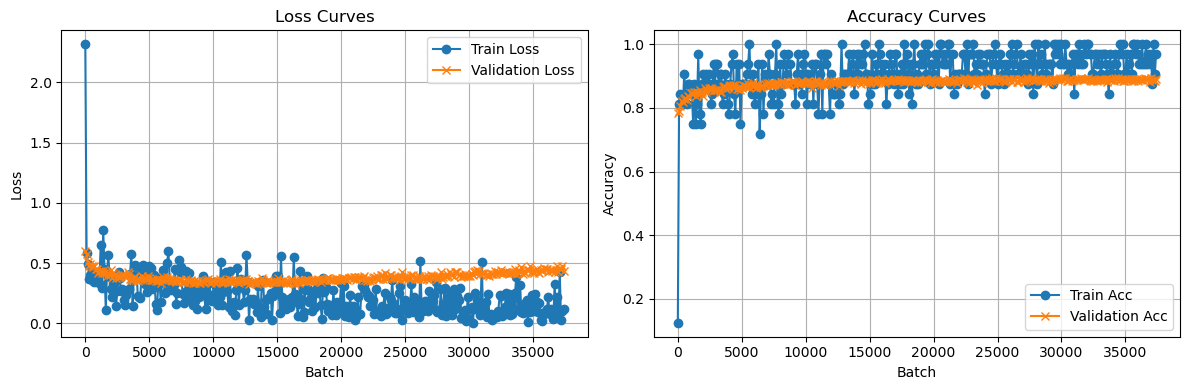

In [11]:
trainer_regression.plot_curves()

完成早停，模型保存实战

In [14]:
from torch import cuda
import torch.nn as nn
import torch.optim as optim
import tqdm as tqdm
import my_train_pro1 as mt

early_stopping = mt.EarlyStopping(patience=5, min_delta=0.01, mode='max')

model_checkpoint = mt.ModelCheckpoint(
    filepath='./checkpoints/fashion_model_epoch_{epoch}.pt',
    monitor='val_acc',
    save_best_only=True,
    mode='max',
    min_delta=0.01
)

tensorboard_callback = mt.TensorBoardCallback(log_dir='./logs')
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

trainer_normalize = mt.Trainer(
    model=model_normalize,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_normalize,
    device=device,
    eval_step=500,
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint,
    tensorboard_callback=tensorboard_callback
)

num_epochs = 100

trainer_normalize.train(num_epochs)


[Step 500] Val Loss: 1.9355 Val Acc: 0.5391
[Step 1000] Val Loss: 1.4386 Val Acc: 0.5963
[Step 1500] Val Loss: 1.1115 Val Acc: 0.6746
Epoch [1/100]  Train Loss: 1.5603  Train Acc: 0.5559
[Step 2000] Val Loss: 0.9411 Val Acc: 0.7104
[Step 2500] Val Loss: 0.8432 Val Acc: 0.7192
[Step 3000] Val Loss: 0.7790 Val Acc: 0.7363
[Step 3500] Val Loss: 0.7342 Val Acc: 0.7436
Epoch [2/100]  Train Loss: 0.8037  Train Acc: 0.7390
[Step 4000] Val Loss: 0.6998 Val Acc: 0.7489
[Step 4500] Val Loss: 0.6771 Val Acc: 0.7576
[Step 5000] Val Loss: 0.6526 Val Acc: 0.7640
[Step 5500] Val Loss: 0.6351 Val Acc: 0.7701
Epoch [3/100]  Train Loss: 0.6539  Train Acc: 0.7690
[Step 6000] Val Loss: 0.6202 Val Acc: 0.7768
[Step 6500] Val Loss: 0.6079 Val Acc: 0.7805
[Step 7000] Val Loss: 0.5936 Val Acc: 0.7873
[Step 7500] Val Loss: 0.5840 Val Acc: 0.7912
Epoch [4/100]  Train Loss: 0.5882  Train Acc: 0.7917
[Step 8000] Val Loss: 0.5747 Val Acc: 0.7937
[Step 8500] Val Loss: 0.5643 Val Acc: 0.8000
[Step 9000] Val Loss: 0.

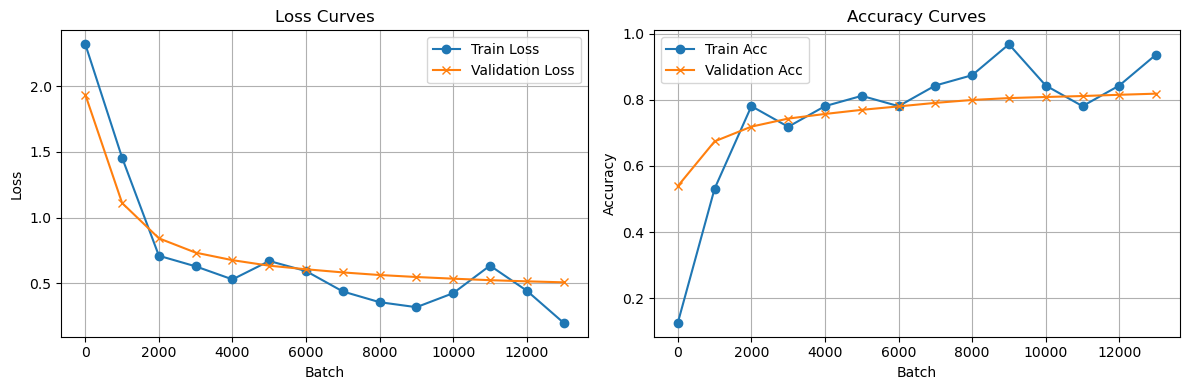

In [16]:
trainer_normalize.plot_curves()